In [1]:
import pandas as pd

In [4]:
fake = pd.read_csv("../data/Fake.csv")
real = pd.read_csv("../data/True.csv")

In [5]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
real["label"] = 1
fake["label"]=0

In [8]:
real

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [9]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [11]:
df = pd.concat([real, fake])
df = df[["text", "label"]]
df.head()

,text,label
0,WASHINGTON (Reuters) - The head of a conservat...,1
1,WASHINGTON (Reuters) - Transgender people will...,1
2,WASHINGTON (Reuters) - The special counsel inv...,1
3,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [14]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df

,text,label
0,WASHINGTON (Reuters) - U.S. President Donald T...,1
1,"Welcome to Trump s America, a.k.a. Trumplandia...",0
2,The election result tonight is hard to swallow...,0
3,WASHINGTON (Reuters) - The Republican National...,1
4,The plans for the Republican convention have s...,0
...,...,...
44893,WASHINGTON (Reuters) - U.S. House Republican S...,1
44894,Two U.S. Marines are reportedly under investig...,0
44895,WASHINGTON (Reuters) - The Trump administratio...,1
44896,BEIJING (Reuters) - A senior Chinese diplomat ...,1


In [15]:
# clean the text
# will create src/data_preprocessing.py
import re

In [18]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"]=df["text"].apply(clean_text)

In [19]:
df

,text,label
0,washington reuters us president donald trump d...,1
1,welcome to trump s america aka trumplandia peo...,0
2,the election result tonight is hard to swallow...,0
3,washington reuters the republican national com...,1
4,the plans for the republican convention have s...,0
...,...,...
44893,washington reuters us house republican speaker...,1
44894,two us marines are reportedly under investigat...,0
44895,washington reuters the trump administration ha...,1
44896,beijing reuters a senior chinese diplomat said...,1


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.75,
    min_df=2,
    ngram_range=(1,2),
    max_features=10000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
from sklearn.metrics import accuracy_score, classification_report

In [28]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9894209354120267
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4765
           1       0.99      0.99      0.99      4215

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [29]:
import pickle

pickle.dump(model, open("lr_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [30]:
# Explainability

import numpy as np

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_fake = np.argsort(coefficients)[:15]
top_real = np.argsort(coefficients)[-15:]

print("Top FAKE indicators:")
print([feature_names[i] for i in top_fake])

print("\nTop REAL indicators:")
print([feature_names[i] for i in top_real])

Top FAKE indicators:
['just', 'image', 'obama', 'don', 'america', 'gop', 'president trump', 'hillary', 'mr', 'didn', 'like', 've', 'doesn', 'trump', 'american']

Top REAL indicators:
['minister', 'republican', 'edt', 'monday', 'reuters president', 'friday', 'thursday', 'tuesday', 'washington', 'wednesday', 'president donald', 'washington reuters', 'trumps', 'said', 'reuters']


In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

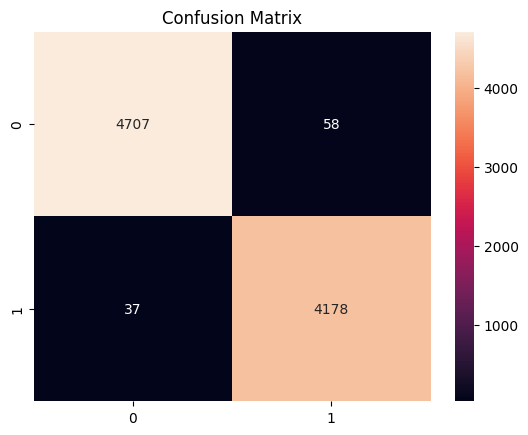

In [35]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()